In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path
from typing import Optional

In [22]:
DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True,exist_ok=True)

In [23]:
TICKERS = ["AAPL","SPCX","GOOG","SPCX"]

In [24]:
BENCHMARK = "SPY"
START = "2021-01-01"
END = None

In [25]:
data = yf.download(TICKERS,start=START,end=END,auto_adjust=True,progress=False)

In [26]:
print(data)

Price            Close                                High              \
Ticker            AAPL        GOOG        SPCX        AAPL        GOOG   
Date                                                                     
2021-01-04  125.740837   85.656792         NaN  129.821751   87.263128   
2021-01-05  127.295471   86.285255         NaN  128.004784   86.619807   
2021-01-06  123.010521   86.006210         NaN  127.334355   86.636154   
2021-01-07  127.208046   88.581497         NaN  127.897922   88.638490   
2021-01-08  128.306030   89.570786         NaN  128.869587   89.701137   
...                ...         ...         ...         ...         ...   
2026-06-29  281.739990  351.279999  164.190002  288.369995  351.970001   
2026-06-30  289.359985  353.329987  170.860001  289.940002  355.390015   
2026-07-01  294.380005  357.890015  157.539993  296.589996  359.559998   
2026-07-02  308.630005  356.179993  162.000000  309.420013  360.989990   
2026-07-06  313.439911  361.299988  16

In [27]:
price_data = {}
for t in TICKERS + [BENCHMARK]:
    price_data[t] = data
    d = price_data[t]
    print(f"{t}: {d.index.min().date()} -> {d.index.max().date()}  ({len(d)} rows)")

AAPL: 2021-01-04 -> 2026-07-06  (1381 rows)
SPCX: 2021-01-04 -> 2026-07-06  (1381 rows)
GOOG: 2021-01-04 -> 2026-07-06  (1381 rows)
SPCX: 2021-01-04 -> 2026-07-06  (1381 rows)
SPY: 2021-01-04 -> 2026-07-06  (1381 rows)


In [28]:
def sanity_check(df, ticker):
    n_missing = int(df.isna().sum().sum())
    gaps = df.index.to_series().diff().dt.days.dropna()
    max_gap = int(gaps.max()) if not gaps.empty else 0
    return {"ticker": ticker, "rows": len(df), "missing_values": n_missing, "max_gap_days": max_gap}

checks = [sanity_check(df, t) for t, df in price_data.items()]
pd.DataFrame(checks)

,ticker,rows,missing_values,max_gap_days
0,AAPL,1381,6830,4
1,SPCX,1381,6830,4
2,GOOG,1381,6830,4
3,SPY,1381,6830,4


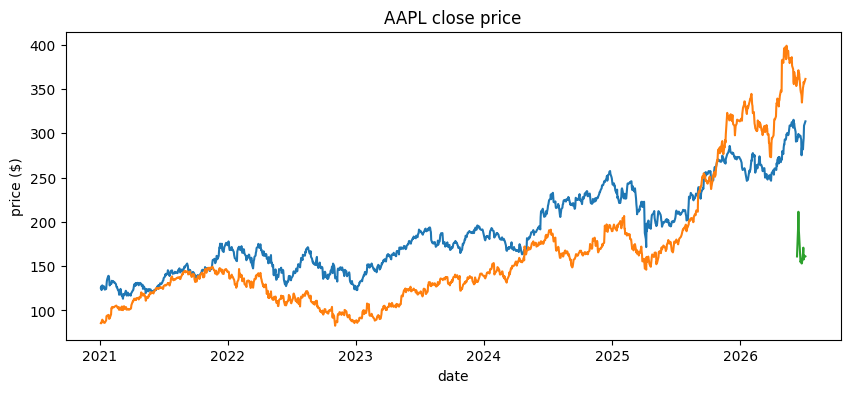

In [29]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(price_data["AAPL"].index, price_data["AAPL"]["Close"])
ax.set_title("AAPL close price")
ax.set_xlabel("date")
ax.set_ylabel("price ($)")
plt.show()